In [1]:
import datetime
import os
from glob import glob
import netCDF4 as nc
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns
from matplotlib.dates import YearLocator, MonthLocator, DateFormatter

### Load data

In [2]:
data_path = 'ME4OH_EN411_OFAM3/data/en4.1.1/1993-2014/'
files = [f for f in glob(os.path.join(data_path, "*.nc"))]

In [23]:
file2read = nc.Dataset(files[0],'r')
print(file2read.variables.keys())

dict_keys(['en4_lat', 'en4_lon', 'en4_ymd', 'en4_ydec', 'en4_maxdepth', 'en4_wmo_inst_type', 'en4_project_name', 'en4_platform_number', 'en4_instrument_type', 'en4_inst_reference', 'en4_data_centre', 'ts_lat', 'ts_lon', 'ts_z', 'ts_dz', 'ts_bound', 'eta_t', 'sst', 'dohc', 'adohc', 'dohc_mask_by_en4_maxdepth', 'temp', 'salt'])


In [3]:
def load_and_filter_ohc(filepath):
    """Load data file, extract variables, filter for layer 1 OHC"""
    file_data = nc.Dataset(filepath,'r')

    # Extract variables
    lat = file_data["ts_lat"][:].data  # Latitude
    long = file_data["ts_lon"][:].data  # Longitude
    time = file_data["en4_ymd"][:].data  # Year , month , day
    mask = file_data["dohc_mask_by_en4_maxdepth"][:].data # Valid profile mask
    dohc1 = file_data["dohc"][:, 0].data  # Layer 1 OHC anomaly target (NOTE: index 0 in python, index 1 in R)
    ssh = file_data["eta_t"][:].data  # Sea surface height

    # Filter to valid OHC
    # Only valid Layer-1 profiles included according to mask and remove NaNs
    idx = [i for i in range(len(mask)) if mask[i, 0] == 1]
    filtered_dohc1 = np.array([dohc1[i] for i in idx])
    filtered_lat = np.array([lat[i] for i in idx])
    filtered_long = np.array([long[i] for i in idx])
    filtered_date = np.array([datetime.date(int(time[i, 0]), int(time[i, 1]), int(time[i, 2])) for i in idx])
    filtered_ssh = np.array([ssh[i] for i in idx])

    # Make df
    ohc_df = pd.DataFrame({
        "Date": filtered_date,
        "Latitude": filtered_lat,
        "Longitude": filtered_long,
        "OHC": filtered_dohc1,
        "SSH": filtered_ssh
    })
    ohc_df = ohc_df.dropna()
    
    return ohc_df
    

In [4]:
# Temporarily filter to only 10 files
# files = files[0:10]

In [5]:
ohc_df = load_and_filter_ohc(files[0])
for path in files[1:]:
    file_df = load_and_filter_ohc(path)
    ohc_df = pd.concat([ohc_df, file_df])

ohc_df

,Date,Latitude,Longitude,OHC,SSH
0,1993-09-12,-65.050003,236.649994,0.343876,-1.691031
1,1993-09-10,-64.050003,221.550003,0.344592,-1.746879
2,1993-09-15,-63.549999,244.350006,0.345307,-1.345561
3,1993-09-11,-63.349998,278.549988,0.345918,-1.107517
4,1993-09-12,-62.849998,219.149994,0.344311,-1.786248
...,...,...,...,...,...
7445,1995-06-28,73.650002,19.150000,0.347956,-0.737022
7446,1995-06-29,73.750000,13.250000,0.348566,-0.766320
7447,1995-06-05,73.750000,13.350000,0.348498,-0.795618
7448,1995-06-29,73.750000,13.350000,0.348606,-0.762963


# EDA

- Amount of data points across time
- Amount of data across space
- Plot OHC vs lat long for a single month?

In [ ]:
ohc_df['Date'] = pd.to_datetime(ohc_df['Date'])

sept_93 = ohc_df.loc[(ohc_df['Date'].dt.month == 9) & (ohc_df['Date'].dt.year == 1993)]
sept_93

,Date,Latitude,Longitude,OHC,SSH
0,1993-09-12,-65.050003,236.649994,0.343876,-1.691031
1,1993-09-10,-64.050003,221.550003,0.344592,-1.746879
2,1993-09-15,-63.549999,244.350006,0.345307,-1.345561
3,1993-09-11,-63.349998,278.549988,0.345918,-1.107517
4,1993-09-12,-62.849998,219.149994,0.344311,-1.786248
...,...,...,...,...,...
7534,1993-09-30,74.150002,25.049999,0.349755,-0.654927
7535,1993-09-30,74.150002,28.049999,0.349318,-0.614948
7536,1993-09-07,74.250000,23.650000,0.348376,-0.676290
7537,1993-09-07,74.250000,25.250000,0.349148,-0.672628


In [7]:
df = ohc_df.copy(deep=True)
df['Date'] = pd.to_datetime(df['Date'])

In [8]:
df.sort_values('Date').reset_index(drop=True)

,Date,Latitude,Longitude,OHC,SSH
0,1993-01-01,5.050000,327.850006,0.366546,0.058901
1,1993-01-01,29.150000,340.250000,0.365908,-0.245369
2,1993-01-01,7.450000,72.650002,0.369750,0.487075
3,1993-01-01,0.150000,319.350006,0.367728,0.051881
4,1993-01-01,0.150000,156.050003,0.371011,0.643025
...,...,...,...,...,...
6170103,2014-12-31,-55.049999,295.149994,0.352809,-0.217292
6170104,2014-12-31,-35.250000,200.850006,0.362071,0.086062
6170105,2014-12-31,-54.849998,62.049999,0.345977,-1.217078
6170106,2014-12-31,-55.250000,81.650002,0.345617,-1.592761


In [ ]:
monthly_means = df.groupby(df['Date'].dt.strftime('%m/%Y'))['OHC'].mean().sort_values()
monthly_std = df.groupby(df['Date'].dt.strftime('%m/%Y'))['OHC'].std().sort_values()

In [32]:
df_monthly = pd.DataFrame(monthly_means).reset_index()
df_monthly['Date'] = pd.to_datetime(df_monthly['Date'], format="%m/%Y")
df_monthly["std"] = monthly_std
df_monthly = df_monthly.sort_values('Date')
df_monthly


,Date,OHC,std
192,1993-01-01,0.365208,NaN
173,1993-02-01,0.365063,NaN
206,1993-03-01,0.365388,NaN
127,1993-04-01,0.364328,NaN
194,1993-05-01,0.365214,NaN
...,...,...,...
79,2014-08-01,0.363326,NaN
111,2014-09-01,0.363922,NaN
126,2014-10-01,0.364277,NaN
136,2014-11-01,0.364518,NaN


Text(0.5, 0, 'Year')

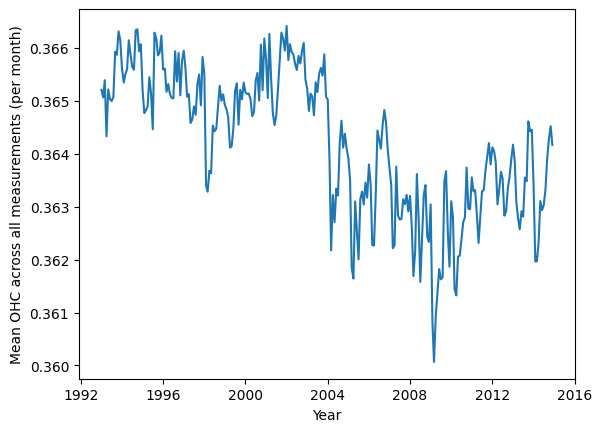

In [30]:
# sns.lineplot(df_monthly, x='Date', y='OHC')
plt.plot(df_monthly['Date'], df_monthly['OHC'])
plt.ylabel("Mean OHC across all measurements (per month)")
plt.xlabel("Year")

In [ ]:
monthly_counts = df.groupby(df['Date'].dt.strftime('%m/%Y'))['OHC'].count().sort_values()

Date
09/1994    11404
12/1996    11850
12/1993    12112
01/2001    12138
01/1997    12142
           ...  
09/2014    38768
05/2013    38958
04/2009    40070
03/2014    40132
03/2009    41066
Name: OHC, Length: 264, dtype: int64

In [15]:
df_counts = pd.DataFrame(monthly_counts).reset_index()
df_counts['Date'] = pd.to_datetime(df_counts['Date'], format="%m/%Y")
df_counts = df_counts.sort_values('Date')
df_counts

,Date,OHC
27,1993-01-01,13324
71,1993-02-01,14610
62,1993-03-01,14416
84,1993-04-01,14908
128,1993-05-01,17116
...,...,...
254,2014-08-01,37850
259,2014-09-01,38768
214,2014-10-01,34376
172,2014-11-01,31270


Text(0.5, 0, 'Year')

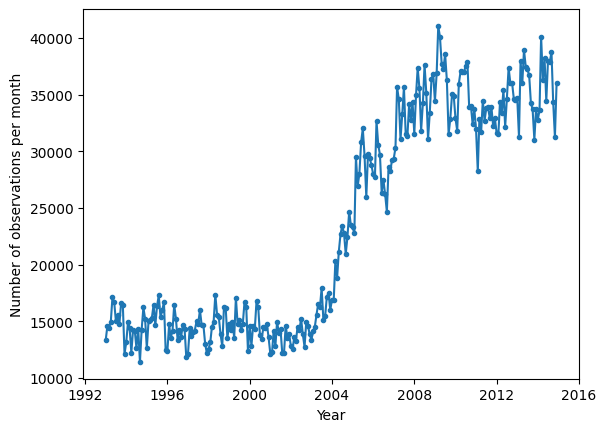

In [20]:
plt.plot(df_counts['Date'], df_counts['OHC'], marker='.')
plt.ylabel("Number of observations per month")
plt.xlabel("Year")